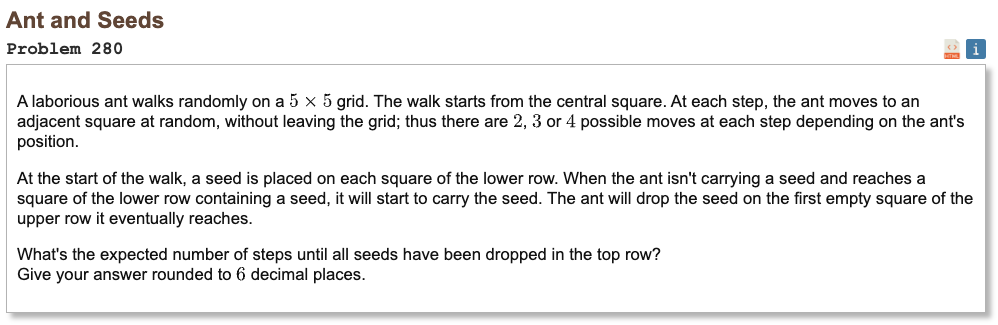

## Initial approach

* treat each situation as a state made of four things: the ant position, whether it is carrying a seed, which bottom seeds are still there, and which top cells are already filled
* start from the center with all five bottom seeds present and no top cell filled
* generate only the states that can actually be reached, which keeps the search much smaller than the full theoretical space
* from every non-finished state, the ant moves uniformly to its allowed neighboring cells, and pickup or drop happens automatically after the move
* the finished states are the ones where all five top cells are filled and the ant is not carrying anything
* for every other state, its expected remaining steps is one move plus the average of the expectations of the next states
* solve those expectations by repeated in-place updates until the start state stops changing at a tiny tolerance
* then round the expectation for the initial state to six decimal places

In [1]:
from collections import deque

def solve():
    size = 5
    all_mask = (1 << size) - 1

    def index(r, c):
        return r * size + c

    neighbors = {}
    for r in range(size):
        for c in range(size):
            pos = index(r, c)
            moves = []
            for dr, dc in ((1, 0), (-1, 0), (0, 1), (0, -1)):
                nr = r + dr
                nc = c + dc
                if 0 <= nr < size and 0 <= nc < size:
                    moves.append(index(nr, nc))
            neighbors[pos] = moves

    start = (index(2, 2), 0, all_mask, 0)
    state_id = {start: 0}
    states = [start]
    queue = deque([start])

    while queue:
        pos, carry, bottom_mask, top_mask = queue.popleft()
        if top_mask == all_mask and carry == 0:
            continue

        for nxt in neighbors[pos]:
            r, c = divmod(nxt, size)
            new_carry = carry
            new_bottom = bottom_mask
            new_top = top_mask

            if carry == 0 and r == size - 1 and ((bottom_mask >> c) & 1):
                new_carry = 1
                new_bottom &= ~(1 << c)
            elif carry == 1 and r == 0 and ((top_mask >> c) & 1) == 0:
                new_carry = 0
                new_top |= 1 << c

            new_state = (nxt, new_carry, new_bottom, new_top)
            if new_state not in state_id:
                state_id[new_state] = len(states)
                states.append(new_state)
                queue.append(new_state)

    transitions = [[] for _ in range(len(states))]
    for i, (pos, carry, bottom_mask, top_mask) in enumerate(states):
        if top_mask == all_mask and carry == 0:
            continue

        for nxt in neighbors[pos]:
            r, c = divmod(nxt, size)
            new_carry = carry
            new_bottom = bottom_mask
            new_top = top_mask

            if carry == 0 and r == size - 1 and ((bottom_mask >> c) & 1):
                new_carry = 1
                new_bottom &= ~(1 << c)
            elif carry == 1 and r == 0 and ((top_mask >> c) & 1) == 0:
                new_carry = 0
                new_top |= 1 << c

            new_state = (nxt, new_carry, new_bottom, new_top)
            transitions[i].append(state_id[new_state])

    expected = [0.0] * len(states)
    start_id = state_id[start]
    tolerance = 1e-14

    while True:
        max_change = 0.0
        for i, outs in enumerate(transitions):
            if not outs:
                continue
            new_value = 1.0 + sum(expected[j] for j in outs) / len(outs)
            change = abs(new_value - expected[i])
            if change > max_change:
                max_change = change
            expected[i] = new_value
        if max_change < tolerance:
            break

    result = round(expected[start_id], 6)
    return result

In [2]:
result = solve()
print("Result:", result)

Result: 430.088247
